In [1]:
import SimpleITK as sitk
import numpy as np
import pyvista as pv
from matplotlib import pyplot as plt
from morphometry.femur import calculate_femoral_torsion
from morphometry.tibia import calculate_tibial_torsion
from morphometry.knee import calculate_knee_rotation_angle
from morphometry.whole_leg import calculate_mikulicz_deviation
from morphometry.ankle import calculate_pma_angle
from morphometry import hip as h

In [2]:
pv.set_jupyter_backend('trame')

In [3]:
hip = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/t1_tse_tra_Huften_bds_10mm_PA000006.nii.gz')
knee = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset002_AugsburgKnee/labelsTr/6: t1_tse_tra Knie PA000006.nii.gz')
ankle = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset003_AugsburgAnkle/labelsTr/t1_tse_tra_OSG_PA000006.nii.gz')

In [4]:
x_ratio = abs(hip.GetSpacing()[2]) / 2 * abs(hip.GetSpacing()[0])

In [5]:
hip_np = sitk.GetArrayFromImage(hip)
knee_np = sitk.GetArrayFromImage(knee)
ankle_np = sitk.GetArrayFromImage(ankle)

p = pv.Plotter()
p.add_mesh(pv.PolyData(np.argwhere(hip_np) * np.array([x_ratio, 1, 1])))
p.show()

# Notes
Code expects:
- anterior - posterior : small - large
- superior - inferior : small - large
- left patient side - right image side and vice versa

This dataset:
- anterior - posterior : large - small for hip
- anterior - posterior : small - large for knee, ankle
- superior - inferior : large small for hip, knee, and ankle

-> flip x axis for hip, knee and ankle

-> flip y axis for hip

In [6]:
# Code expects superior - inferior axis to be low - high, i.e. 0 is the most proximal slice. 
# In Augsburg Dataset, this is oppsoite, so we flip the axis
hip_np = hip_np[::-1]
knee_np = knee_np[::-1]
ankle_np = ankle_np[::-1]
# Code also expects anterior - posterior axis to be low - high, i.e. 0 is the most anterior slice.
# In Augsburg Dataset, this is also opposite, so we flip the axis
hip_np = hip_np[:, ::-1]


In [7]:
hip_np.shape, knee_np.shape

((19, 324, 384), (38, 324, 384))

In [8]:
left_hip = hip_np[:, :, :hip_np.shape[2]//2]
right_hip = hip_np[:, :, hip_np.shape[2]//2:]

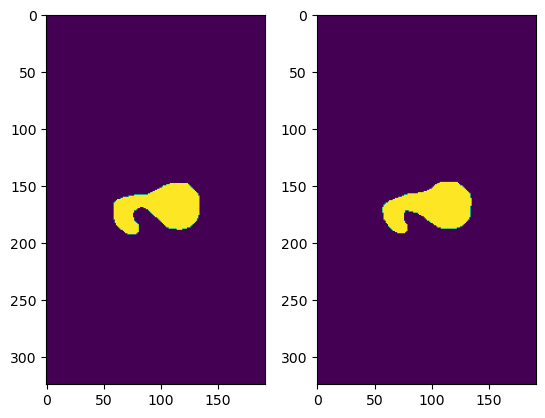

In [9]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(left_hip[7])
ax[1].imshow(right_hip[7][:, ::-1])
plt.show()

In [10]:
left_knee = knee_np[:, :, :knee_np.shape[2]//2]
right_knee = knee_np[:, :, knee_np.shape[2]//2:]

In [11]:
left_ankle = ankle_np[:, :, :ankle_np.shape[2]//2]
right_ankle = ankle_np[:, :, ankle_np.shape[2]//2:]

from morphometry.hip import get_femoral_head_center
from skimage import measure
from morphometry.utils import points_on_circle

r, center, layer_high, layer_low = get_femoral_head_center(left_hip, side='left', segmentation_label=1, return_layers=True, x_ratio=x_ratio)
center = center.astype(np.int16)

layer_selected = None
fig, ax = plt.subplots(left_hip.shape[0], 1, figsize=(10, 10 * left_hip.shape[0]))
for n in range(left_hip.shape[0] - 1, 0, -1):
    contour_length = len(measure.find_contours(left_hip[n], 0.8))
    on_circle = points_on_circle(left_hip[n], r * 2, center[1:])
    ax[n].imshow(left_hip[n])
    ax[n].add_patch(plt.Circle((center[2], center[1]), r * 2, color='r', fill=False))

plt.show()

In [12]:
# pcu = h.get_femoral_head_center(left_hip, side='left', segmentation_label=1, x_ratio=x_ratio)

In [13]:
import importlib
importlib.reload(h)
r, center = h.get_femoral_head_center(left_hip, side='left', segmentation_label=1, x_ratio=x_ratio)
pc = np.argwhere(left_hip).astype(np.float32)
# pc[:, 0] *= x_ratio
p = pv.Plotter()
p.add_mesh(pv.PolyData(pc))
# p.add_mesh(pv.PolyData(pcu), color='red')
p.add_mesh(pv.Sphere(radius=r, center=center))
p.show()

[[ 28.03903158]
 [167.17546667]
 [113.69875324]]


Widget(value='<iframe src="http://localhost:36467/index.html?ui=P_0x7339913ec9d0_0&reconnect=auto" class="pyvi…

In [14]:
center

array([  5.1271372 , 167.17546667, 113.69875324])

[[ 28.03903158]
 [167.17546667]
 [113.69875324]]


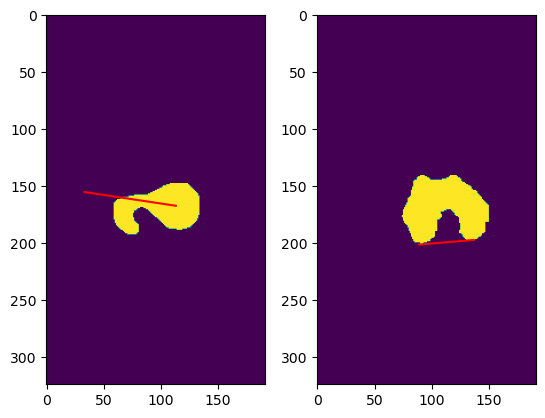

13.294407300674315

In [15]:
calculate_femoral_torsion(left_hip, left_knee, side='left', segmentation_label=1, x_ratio=x_ratio, plot=True)

[[ 30.27775939]
 [167.10903499]
 [ 81.00609708]]


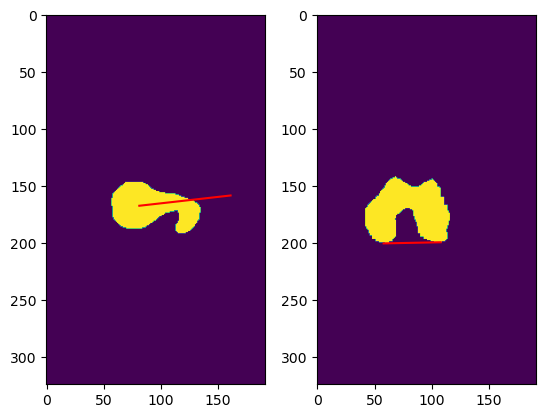

5.2730238920636525

In [16]:
calculate_femoral_torsion(right_hip, right_knee, side='right', segmentation_label=1, x_ratio=x_ratio, plot=True)

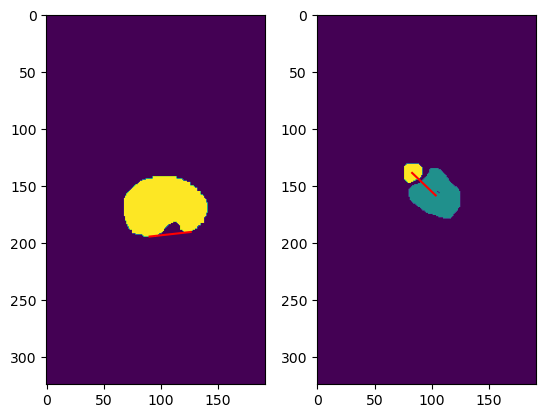

49.978379534875366

In [17]:
calculate_tibial_torsion(left_knee, left_ankle, tibia_label_knee=2, tibia_label_ankle=1, fibula_label=2, plot=True)

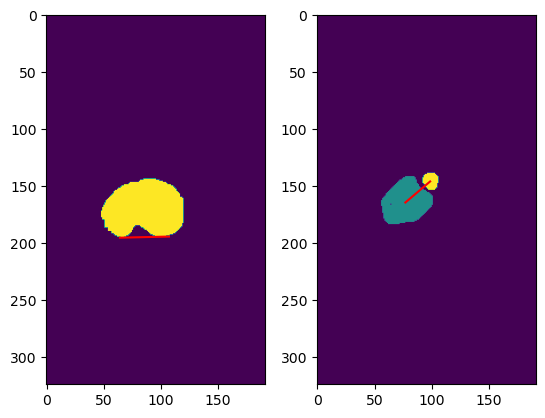

39.03137056754556

In [18]:
calculate_tibial_torsion(right_knee, right_ankle, tibia_label_knee=2, tibia_label_ankle=1, fibula_label=2, side='right', plot=True)

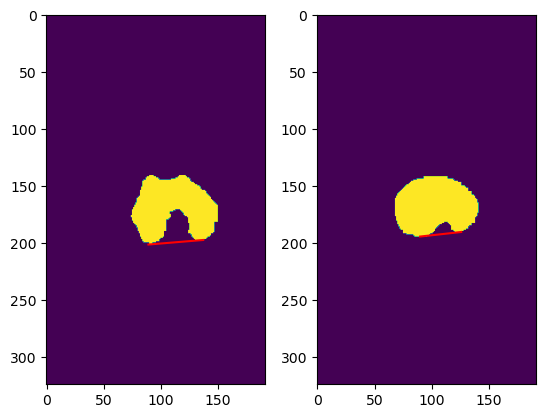

1.5765500551837375

In [19]:
calculate_knee_rotation_angle(left_knee, femur_label=1, tibia_label=2, plot=True)

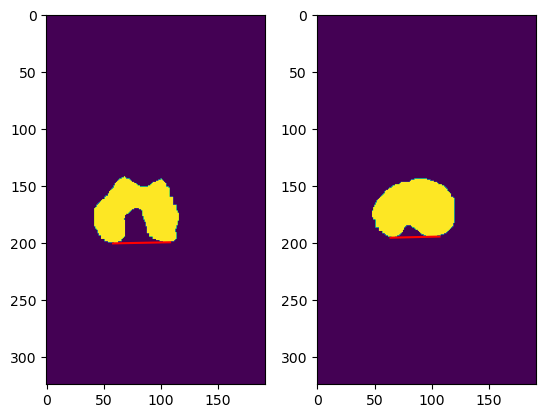

0.18645701569383197

In [20]:
calculate_knee_rotation_angle(right_knee, femur_label=1, tibia_label=2, plot=True)

In [20]:
a = np.array([-79.96983899, 629.96007327])
b = np.array([-94.57216339, -234.91649584])
ab = b - a
c = np.array([-88.3739283, 178.10822187])
np.cross(ab, c)

array(-79033.33394093)

In [19]:
a = np.array([10, 0, 0])
b = np.array([-10, 5, 5])
ab = b - a
c = np.array([0, 0, 10])
np.cross(ab, c)

array([ 50, 200,   0])

In [12]:
calculate_mikulicz_deviation(left_hip, left_knee, left_ankle, hip, knee, ankle, side='left', x_ratio=x_ratio, hip_x_axis_flipped=True)

[ 28.03903158 167.17546667 113.69875324]
Femoral head center: [629.96007327  -1.61336443 -79.96983899], Knee center: [178.10822187  14.79857135 -88.3739283 ], Ankle center: [-234.91649584    9.68930051  -94.57216339]
Knee center is to the left image side of the Mikulicz line.


0.7750436365395209

In [13]:
calculate_mikulicz_deviation(right_hip, right_knee, right_ankle, hip, knee, ankle, side='right', x_ratio=x_ratio, hip_x_axis_flipped=True)

[ 30.27775939 167.10903499  81.00609708]
Femoral head center: [ 625.86639958   -1.54070478 -115.72743166], Knee center: [ 176.08586293   17.21731364 -114.73538595], Ankle center: [-236.7597238     1.92326647 -112.42614379]
Knee center is to the left image side of the Mikulicz line.


0.7292682891278405

In [23]:
calculate_pma_angle(left_ankle, 1, 2)

[ 14.         172.49122807 116.24561404] [ 18.         132.82926829  77.70731707]


134.03188657466745

In [24]:
calculate_pma_angle(right_ankle, 1, 2)

[ 14.  177.5  62.5] [ 18.   145.32 103.68]


38.219056869672855

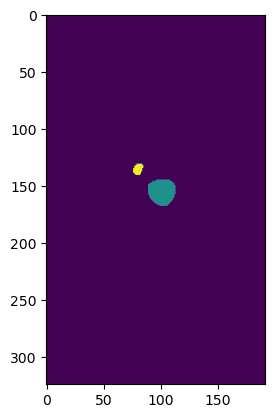

In [25]:
plt.imshow(left_ankle[0])

In [37]:
from morphometry.utils import angle_between

p1 = np.array([14, 62.5]) * np.array([x_ratio, 1])
p2 = np.array([18, 103.68]) * np.array([x_ratio, 1])
p1_p2 = p2 - p1

p3_p4 = np.array([0, 1])

np.degrees(angle_between(p1_p2, p3_p4))

27.977439779366723

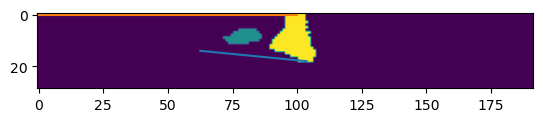

In [35]:
plt.imshow(right_ankle[:, 145])
plt.plot([p1[2], p2[2]], [p1[0] / x_ratio, p2[0] / x_ratio])
plt.plot([0, 100], [0, 0])
plt.show()